# Stacking Ensemble — Apparatus Expert Split

3-stage pipeline for Gym99 action recognition with extreme class imbalance:

| Stage | What happens |
|---|---|
| **1 — Expert Training** | Train 4 ST-GCN models, one per apparatus (VT / FX / BB / UB), using `train_gym99.py --apparatus` flag |
| **2 — Feature Extraction** | Pass all samples through the 4 frozen experts; collect 256-dim vector before final FC; concat → 1024-dim super-vector |
| **3 — Meta-Learner** | Train a lightweight MLP `1024 → 512 → Dropout(0.5) → 256 → 99`; evaluate with Confusion Matrix |

**Apparatus label mapping:**
```
VT  Vault           Clabel  0 –  5  (  6 classes)
FX  Floor Exercise  Clabel  6 – 40  ( 35 classes)
BB  Balance Beam    Clabel 41 – 73  ( 33 classes)
UB  Uneven Bars     Clabel 74 – 98  ( 25 classes)
```

In [1]:
# ── Cell 1: Environment & paths ───────────────────────────────────────────────
import os
import subprocess
import sys
from pathlib import Path

try:
    from dotenv import load_dotenv
except ImportError:
    subprocess.run([sys.executable, '-m', 'pip', 'install', 'python-dotenv', '-q'], check=True)
    from dotenv import load_dotenv

_nb_dir = Path(globals().get('__vsc_ipynb_file__', __file__) if '__file__' in dir() else '.').resolve().parent
for _candidate in [_nb_dir / '.env', _nb_dir.parent / '.env', Path('.env')]:
    if _candidate.exists():
        load_dotenv(_candidate)
        print(f'Loaded .env from {_candidate}')
        break
else:
    print('No .env found — using Colab defaults')

REPO_DIR   = os.getenv('REPO_DIR',   '/kaggle/working/Yolo-ST-GCN')
BRANCH     = os.getenv('BRANCH',     'experiment-bonestream')
GYM288_PKL = os.getenv('GYM288_PKL', '/kaggle/working/Gym288-skeleton/gym_288_skeleton.pkl')
GYM99_PKL  = os.getenv('GYM99_PKL',  '/kaggle/working/Gym99-from-Gym288/gym99_from_gym288.pkl')
OUT_BASE   = os.getenv('OUT_DIR',    'outputs/ensemble')

APPARATUS_LIST   = ['VT', 'FX', 'BB', 'UB', 'FX_baseline']
APPARATUS_RANGES = {'VT': (0, 5), 'FX': (6, 40), 'FX_baseline' : (6, 40), 'BB': (41, 73), 'UB': (74, 98)}
EXPERT_DIRS      = {ap: f'{OUT_BASE}/expert_{ap}' for ap in APPARATUS_LIST}
FEATURES_DIR     = f'{OUT_BASE}/features'
META_DIR         = f'{OUT_BASE}/meta_learner'

print(f'REPO_DIR   = {REPO_DIR}')
print(f'GYM288_PKL = {GYM288_PKL}')
print(f'GYM99_PKL  = {GYM99_PKL}')
print(f'OUT_BASE   = {OUT_BASE}')

No .env found — using Colab defaults
REPO_DIR   = /kaggle/working/Yolo-ST-GCN
GYM288_PKL = /kaggle/working/Gym288-skeleton/gym_288_skeleton.pkl
GYM99_PKL  = /kaggle/working/Gym99-from-Gym288/gym99_from_gym288.pkl
OUT_BASE   = outputs/ensemble


In [2]:
# ── Cell 2: Repo setup ────────────────────────────────────────────────────────
REPO_URL = 'https://github.com/schizocatto/Yolo-ST-GCN.git'

if not Path(REPO_DIR).exists():
    print('Cloning repo...')
    subprocess.run(
        ['git', 'clone', '-b', BRANCH, '--single-branch', REPO_URL, REPO_DIR],
        check=True,
    )
else:
    print('Repo exists — pulling latest...')
    subprocess.run(['git', '-C', REPO_DIR, 'fetch', 'origin', BRANCH], check=True)
    subprocess.run(['git', '-C', REPO_DIR, 'checkout', BRANCH], check=True)
    subprocess.run(['git', '-C', REPO_DIR, 'pull', 'origin', BRANCH], check=True)

os.chdir(REPO_DIR)
if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)

print('Working dir:', os.getcwd())

Cloning repo...


Cloning into '/kaggle/working/Yolo-ST-GCN'...


Working dir: /kaggle/working/Yolo-ST-GCN


In [3]:
# ── Cell 3: Download Gym288 dataset ───────────────────────────────────────────
if Path(GYM288_PKL).exists():
    print(f'Gym288 pickle found: {GYM288_PKL}')
else:
    print('Downloading from HuggingFace...')
    subprocess.run([sys.executable, '-m', 'pip', 'install', 'huggingface_hub', '-q'], check=True)
    from huggingface_hub import snapshot_download
    download_dir = Path(GYM288_PKL).parent
    download_dir.mkdir(parents=True, exist_ok=True)
    snapshot_download(
        repo_id='Lozumi/Gym288-skeleton',
        repo_type='dataset',
        local_dir=str(download_dir),
        local_dir_use_symlinks=False,
    )
    pkl_candidates = sorted(download_dir.rglob('*.pkl'))
    if not pkl_candidates:
        raise FileNotFoundError('No .pkl found after Gym288 download.')
    GYM288_PKL = str(pkl_candidates[0])
    print(f'Downloaded: {GYM288_PKL}')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:202: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `snapshot_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Downloaded: /kaggle/working/Gym288-skeleton/gym_288_skeleton.pkl


In [4]:
# ── Cell 4.5: Generate Custom Augmentation Policy cho môn FX ──
import json
import os

# Đường dẫn lưu file trên môi trường Kaggle
POLICY_PATH = '/kaggle/working/fx_aug_policy.json'

fx_policy = {
  "0": {
    "horizontal_flip_prob": 0.5,
    "scale_prob": 0.2,
    "scale_range": [0.95, 1.05],
    "random_shift": False,
    "random_move": False,
    "noise_std": 0.0,
    "joint_drop_prob": 0.0,
    "subsample_prob": 0.0
  },
  "1": {
    "horizontal_flip_prob": 0.5,
    "scale_prob": 0.5,
    "scale_range": [0.9, 1.1],
    "random_shift": True,
    "random_move": True,
    "move_angle": 5.0,     # Xoay nhẹ 5 độ
    "move_scale": 0.05,
    "move_trans": 0.0,     # TẮT tịnh tiến (để bảo toàn bbox_norm)
    "noise_std": 0.005,
    "joint_drop_prob": 0.05,
    "subsample_prob": 0.3,
    "subsample_factor_range": [0.9, 1.1]
  },
  "2": {
    "horizontal_flip_prob": 0.5,
    "scale_prob": 0.8,
    "scale_range": [0.85, 1.15],
    "random_shift": True,
    "random_move": True,
    "move_angle": 10.0,    # Xoay mạnh hơn 10 độ
    "move_scale": 0.1,
    "move_trans": 0.0,     # TẮT tịnh tiến
    "noise_std": 0.01,
    "joint_drop_prob": 0.1,
    "subsample_prob": 0.5,
    "subsample_factor_range": [0.8, 1.2],
    "temporal_reverse_prob": 0.0  # TẮT tua ngược (giữ đúng logic vật lý)
  }
}

# Lưu file JSON
with open(POLICY_PATH, 'w') as f:
    json.dump(fx_policy, f, indent=4)

print(f"✅ Đã tạo thành công file custom policy tại: {POLICY_PATH}")

✅ Đã tạo thành công file custom policy tại: /kaggle/working/fx_aug_policy.json


In [5]:
# # ── Cell 6: Train Expert BB — 33 classes (Clabel 41-73) ──
# import sys, importlib

# sys.argv = [
#     'train_gym99.py',
#     '--auto_build_from_gym288',
#     '--gym288_dataset_path', GYM288_PKL,
#     '--dataset_path',        GYM99_PKL,
#     '--out_dir',             EXPERT_DIRS['FX_baseline'],
#     '--apparatus',           'FX',
#     '--epochs',              '80',
#     '--batch_size',          '128',
#     '--lr',                  '0.001',
#     '--num_workers',         '2',
#     '--joint_spec_name',     'coco18',
#     '--center_norm',
#     '--use_augment_feeder',
#     '--use_weighted_sampler',
#     '--grad_clip_norm',      '1.0',
# ]

# import scripts.train_gym99 as _train_script
# importlib.reload(_train_script)
# print(f'\n>>> Training Expert BB (33 classes) ...')
# _train_script.main()
# print(f'\n✅ Expert BB done.')

# ── Cell 5: Train Expert FX — 35 classes (Clabel 6-40) ──
import sys, importlib

sys.argv = [
    'train_gym99.py',
    '--auto_build_from_gym288',
    '--gym288_dataset_path', GYM288_PKL,
    '--dataset_path',        GYM99_PKL,
    '--out_dir',             EXPERT_DIRS['FX'],
    '--apparatus',           'FX',
    '--epochs',              '70',           # GIẢM epoch xuống vì 1 epoch giờ rất dài
    '--batch_size',          '32',
    '--lr',                  '0.001',
    '--num_workers',         '2',
    '--joint_spec_name',     'coco18',
    '--loss_name',           'focal',
    '--focal_alpha_mode',    'sqrt_inverse',
    '--bbox_norm',
    '--warmup_epochs',       '8',
    '--use_augment_feeder',
    '--aug_config_path',     '/kaggle/working/fx_aug_policy.json',
    '--use_two_stream',
    '--use_weighted_sampler',
    '--oversample_ratio',    '3.0',          # TĂNG GẤP 2 LẦN DỮ LIỆU
    '--grad_clip_norm',      '1.0',
    '--weight_decay',        '0.0005',
    # '--label_smoothing',     '0.1'           # (Nếu bạn đã cập nhật file losses.py)
]

import scripts.train_gym99 as _train_script
importlib.reload(_train_script)
print(f'\n>>> Training Expert FX (35 classes) with 2x Oversampling...')
_train_script.main()
print(f'\n✅ Expert FX done.')


>>> Training Expert FX (35 classes) with 2x Oversampling...
Building Gym99-from-Gym288 pickle...
Gym99 mapping stats: direct=34240 minus1=1625 plus1=800 train=27624 test=9041
Device: cuda
Loading Gym99-skeleton dataset...
[apparatus=FX] class range [6, 40] → local classes [0, 34]  train=5824  val=2411
[corrupt filter] train: 5824 → 5280 (removed 544)
[corrupt filter] val:   2411 → 2181 (removed 230)
Loaded 36665 samples  train=5280  test=2181
[info] Applying bbox normalization to train and val tensors...
num_classes=35 (apparatus=FX, local labels 0-34)
[info] Using in-memory tensors; forcing num_workers=0 to avoid dataloader overhead.
[info] Loaded custom augmentation policy from: /kaggle/working/fx_aug_policy.json

[SkeletonFeeder] Augmentation tier assignment (35 classes, 5280 samples)
  Tier 0 [Majority (light)] — 18 classes, 3928 samples (74.4%)
      class   16: 130 samples
      class    1: 131 samples
      class   19: 132 samples
      class   15: 132 samples
      class   25:


Epoch 1/70 [train]: 100%|██████████| 495/495 [01:53<00:00,  4.11it/s]
                                                                     
Epoch 1/70 [val]:  99%|█████████▊| 68/69 [00:03<00:00, 17.72it/s]
                                                                 

Epoch 1/70  train_loss=2.5032  train_acc=0.1751  val_loss=1.8450  val_acc=0.2077  val_f1=0.1722



Epoch 2/70 [train]: 100%|██████████| 495/495 [02:02<00:00,  3.95it/s]
                                                                     
Epoch 2/70 [val]:  99%|█████████▊| 68/69 [00:03<00:00, 17.72it/s]
                                                                 

Epoch 2/70  train_loss=1.2289  train_acc=0.4061  val_loss=1.0896  val_acc=0.3741  val_f1=0.2991


...

Epoch 68/70  train_loss=0.0067  train_acc=0.9979  val_loss=0.7572  val_acc=0.7506  val_f1=0.5486



Epoch 69/70 [train]: 100%|██████████| 495/495 [01:55<00:00,  4.34it/s]
                                                                      
Epoch 69/70 [val]:  99%|█████████▊| 68/69 [00:03<00:00, 18.73it/s]
                                                                  

Epoch 69/70  train_loss=0.0072  train_acc=0.9979  val_loss=0.7453  val_acc=0.7584  val_f1=0.5599



Epoch 70/70 [train]: 100%|██████████| 495/495 [01:55<00:00,  4.26it/s]
                                                                      
Epoch 70/70 [val]:  99%|█████████▊| 68/69 [00:03<00:00, 18.69it/s]
                                                                  

Epoch 70/70  train_loss=0.0070  train_acc=0.9984  val_loss=0.7531  val_acc=0.7570  val_f1=0.5567
Saved periodic checkpoint: outputs/ensemble/expert_FX/stgcn_gym99_coco18_2s_expert_FX_epoch70.pth
Saved weights: outputs/ensemble/expert_FX/stgcn_gym99_coco18_2s_expert_FX.pth
Test Top-1 Accuracy: 0.7570
Test Macro-F1     : 0.5567

✅ Expert FX done.


Joint weight: 0.6863524913787842, Bone weight: 0.3136475086212158

[Val] FX - Acc: 0.6864 | Macro F1: 0.5256


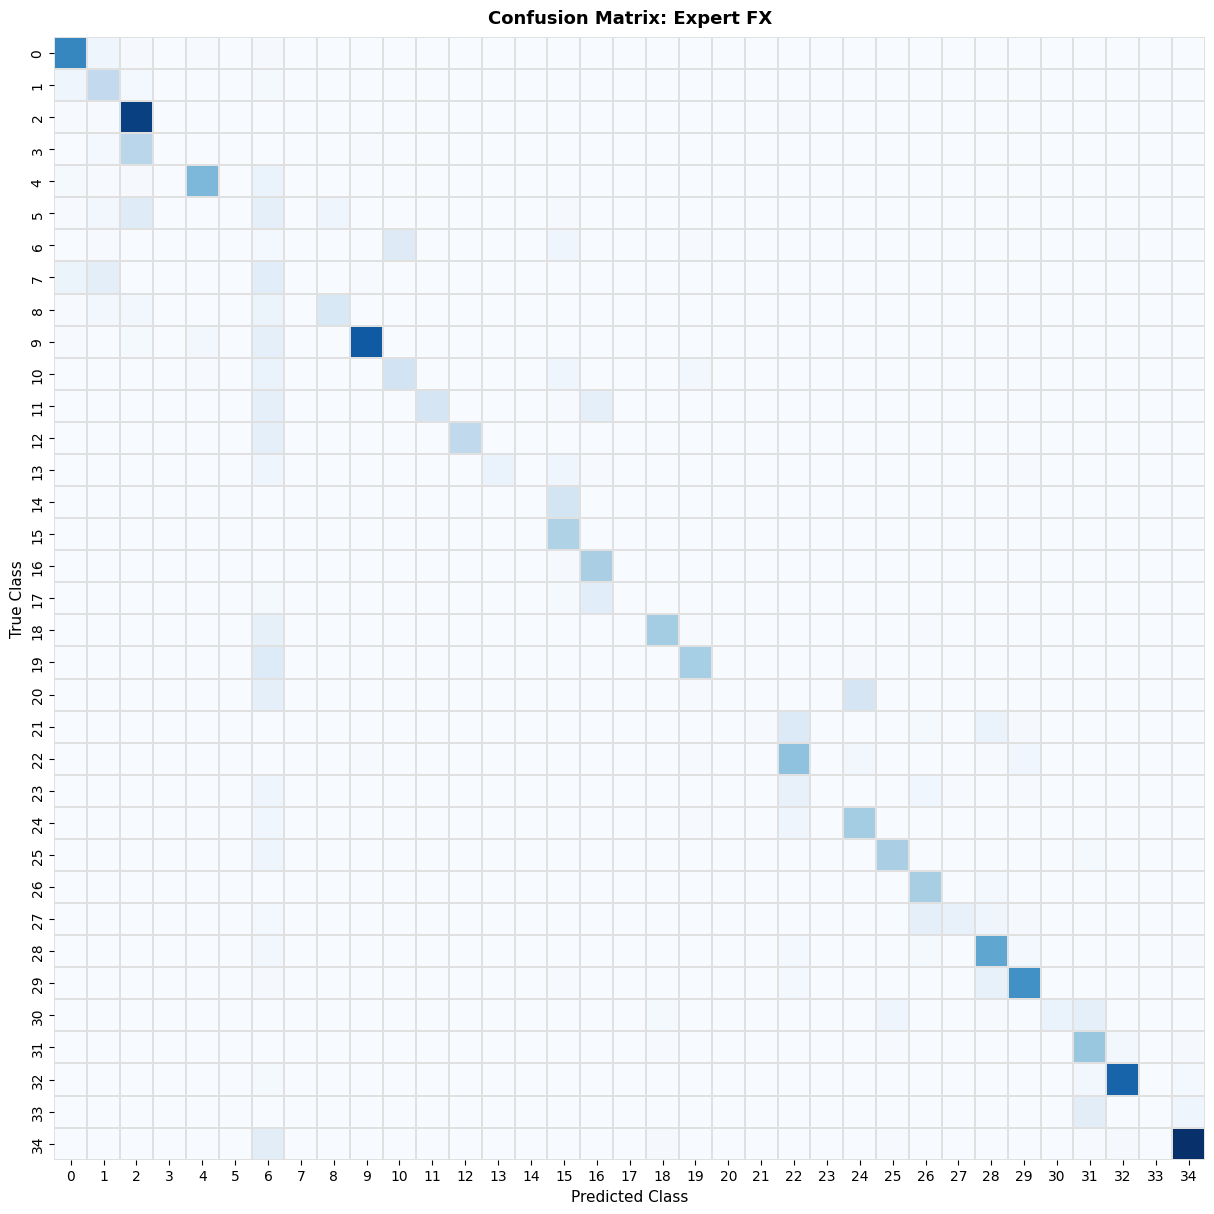

In [6]:
# ── Evaluate Expert FX ───────────────────────────────────────
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score
from torch.utils.data import DataLoader, TensorDataset

from src.two_stream_stgcn import TwoStream_STGCN
from src.checkpointing import load_checkpoint
from src.gym99_dataset import build_gym99_data_tensors
from src.skeleton_utils import bbox_normalize, center_normalize

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
ap = 'FX'
lo, hi = APPARATUS_RANGES[ap]
num_cls = hi - lo + 1

# if not all(k in globals() for k in ['GYM99_J_DATA', 'GYM99_B_DATA', 'GYM99_LABELS', 'GYM99_FLAGS']):
#     print(f'Loading data into RAM for sequential evaluation...')
j_data, b_data, labels, flags, _, _ = build_gym99_data_tensors(
    dataset_path=GYM99_PKL, joint_spec_name='coco18',
    split='all', keep_unknown_split=False, return_bone_data=True
)
j_data = bbox_normalize(j_data)
b_data = bbox_normalize(b_data)
# j_data = center_normalize(j_data, 17) # COCO18 center is 17
globals()['GYM99_J_DATA'] = j_data
globals()['GYM99_B_DATA'] = b_data
globals()['GYM99_LABELS'] = labels.astype(int)
globals()['GYM99_FLAGS']  = flags.astype(int)

j_data = GYM99_J_DATA
b_data = GYM99_B_DATA
labels_np = GYM99_LABELS
flags_np = GYM99_FLAGS

mask = (labels_np >= lo) & (labels_np <= hi)
val_mask = mask & (flags_np == 0)
val_j = torch.tensor(j_data[val_mask], dtype=torch.float32)
val_b = torch.tensor(b_data[val_mask], dtype=torch.float32)
val_y = torch.tensor(labels_np[val_mask] - lo, dtype=torch.long)

loader = DataLoader(TensorDataset(val_j, val_b, val_y), batch_size=64, shuffle=False)

weights_path = f"{EXPERT_DIRS[ap]}/stgcn_gym99_coco18_2s_expert_{ap}.pth"
model = TwoStream_STGCN(num_classes=num_cls, joint_spec='coco18').to(device)
state_dict, _ = load_checkpoint(weights_path, map_location=device)
model.load_state_dict(state_dict)
model.eval()

stream_alpha = torch.sigmoid(model.alpha_logit).item()

print(f"Joint weight: {stream_alpha}, Bone weight: {1 - stream_alpha}")

preds = []
with torch.no_grad():
    for bj, bb, _ in loader:
        out = model(bj.to(device), bb.to(device))
        preds.extend(out.argmax(1).cpu().tolist())

gts = val_y.tolist()
acc = accuracy_score(gts, preds)
mf1 = f1_score(gts, preds, average='macro', zero_division=0)
print(f"\n{'='*40}\n[Val] {ap} - Acc: {acc:.4f} | Macro F1: {mf1:.4f}\n{'='*40}")

cm = confusion_matrix(gts, preds, labels=list(range(num_cls)))
plt.figure(figsize=(max(5, num_cls*0.35), max(4, num_cls*0.35)))
sns.heatmap(cm, annot=num_cls <= 20, fmt='d', cmap='Blues',
            xticklabels=list(range(num_cls)), yticklabels=list(range(num_cls)),
            linewidths=0.3, linecolor='#e0e0e0', cbar=False)
plt.title(f"Confusion Matrix: Expert {ap}", fontsize=13, fontweight='bold', pad=10)
plt.ylabel('True Class', fontsize=11)
plt.xlabel('Predicted Class', fontsize=11)
plt.tight_layout()
plt.show()


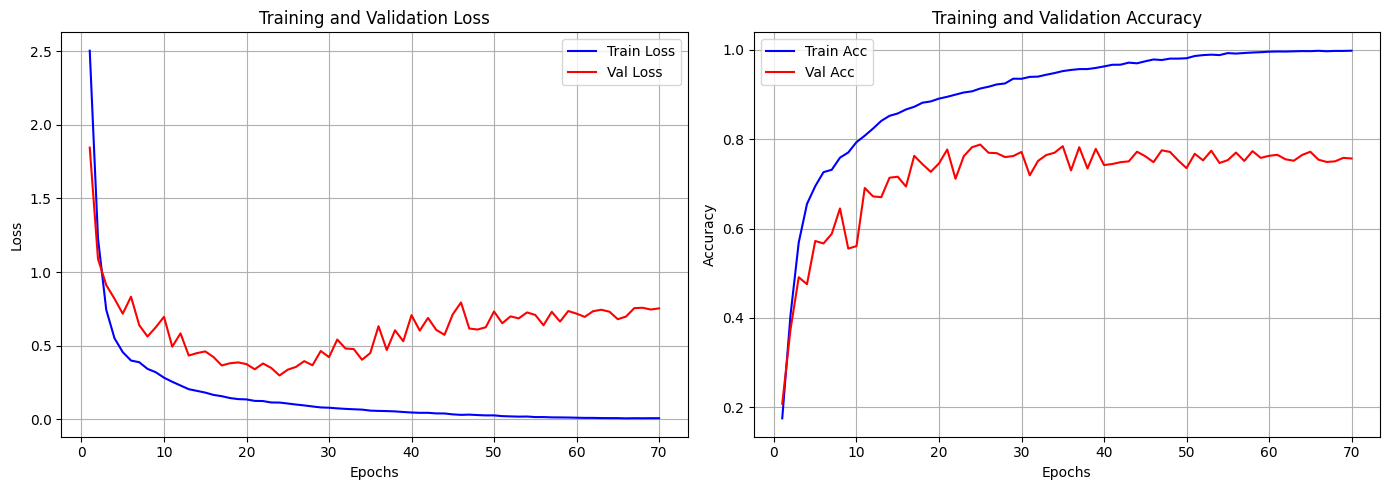

In [7]:
import json
import matplotlib.pyplot as plt
import os

# Đường dẫn tới file history.json của bạn
history_file = os.path.join(EXPERT_DIRS['FX'], 'history.json')

with open(history_file, 'r') as f:
    history = json.load(f)

epochs = range(1, len(history['train_loss']) + 1)

plt.figure(figsize=(14, 5))

# Biểu đồ Loss
plt.subplot(1, 2, 1)
plt.plot(epochs, history['train_loss'], 'b-', label='Train Loss')
plt.plot(epochs, history['val_loss'], 'r-', label='Val Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Biểu đồ Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs, history['train_acc'], 'b-', label='Train Acc')
plt.plot(epochs, history['val_acc'], 'r-', label='Val Acc')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()